# **Hand Written Digits Detector Using CNN**

## Import libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# Visualize the images

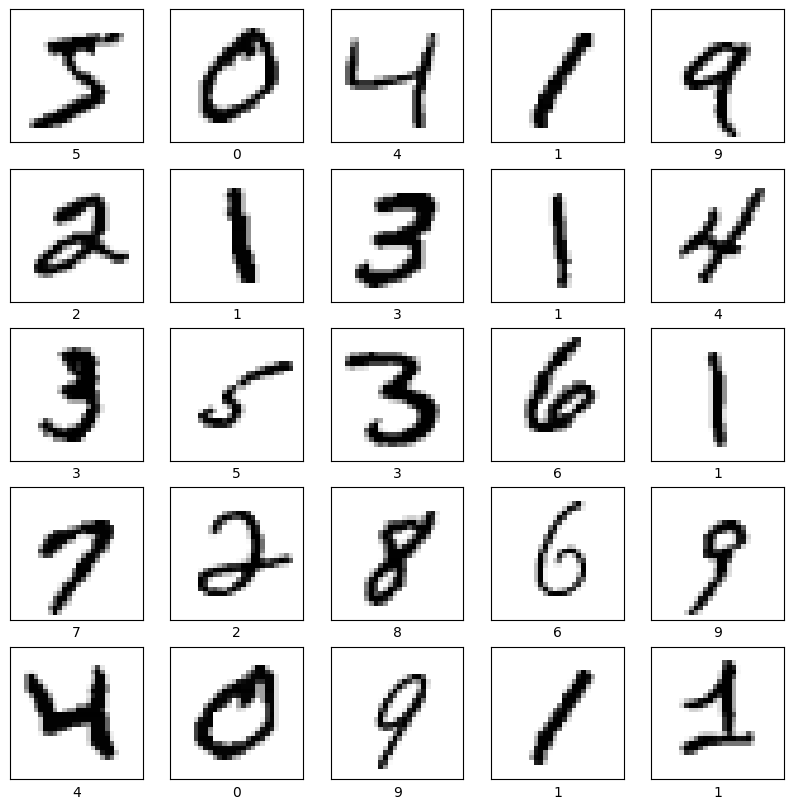

In [3]:
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(X_train[i], cmap = plt.cm.binary)
  plt.xlabel(y_train[i])
plt.show()

## See pixels

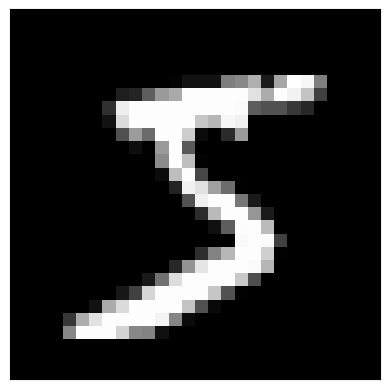

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0 
  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0 
  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0 
  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   0   0   0   0 

In [4]:
plt.imshow(X_train[0],cmap = "gray")
plt.xticks([])
plt.yticks([])
plt.show()

for row in X_train[0]:
  for pixel in row:
    print("{:3}".format(pixel),end = " ")
  print()

## length of training and testing images.

In [5]:
print("Training dataset length",len(X_train))
print("Testing dataset length",len(X_test))
print("Shape of image",X_train[0].shape)


Training dataset length 60000
Testing dataset length 10000
Shape of image (28, 28)


## Normalization

In [6]:
X_train = X_train.astype("float")/255.0
X_test = X_test.astype("float")/255.0

## See pixels after normalization

In [7]:
for row in X_train[0]:
  for pixel in row:
    print("{:0.3f}".format(pixel),end=" ")
  print()

0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.012 0.071 0.071 0.071 0.494 0.533 0.686 0.102 0.651 1.000 0.969 0.498 0.000 0.000

## Build model

In [8]:
import tensorflow as tf
from tensorflow.keras import layers
input_layers = tf.keras.Input(shape = [28,28,1])

model = tf.keras.Sequential([
        input_layers,
        layers.Conv2D(filters = 10, kernel_size = (3,3), activation = 'relu'),
        layers.Conv2D(filters = 10, kernel_size = (3,3), activation = 'relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(filters = 10, kernel_size = (3,3), activation = 'relu'),
        layers.Conv2D(filters = 10, kernel_size = (3,3), activation = 'relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(10, activation = 'softmax')
])

## Summary

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 10)       │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,440 (17.34 KB)

 Trainable params: 4,440 (17.34 KB)

 Non-trainable params: 0 (0.00 B)

## Complie the model

In [10]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

## Training

In [11]:
model.fit(X_train, y_train, epochs = 5, batch_size = 64, validation_split = 0.2)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8750 - loss: 0.4006 - val_accuracy: 0.9542 - val_loss: 0.1543
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9631 - loss: 0.1188 - val_accuracy: 0.9712 - val_loss: 0.0931
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9731 - loss: 0.0859 - val_accuracy: 0.9756 - val_loss: 0.0776
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9787 - loss: 0.0699 - val_accuracy: 0.9783 - val_loss: 0.0736
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9804 - loss: 0.0619 - val_accuracy: 0.9780 - val_loss: 0.0672


## Testing

In [12]:
test_loss,test_acc = model.evaluate(X_test,y_test)
print("Test loss:",test_loss)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9801 - loss: 0.0582
Test loss: 0.058151476085186005
Test Accuracy: 0.9800999760627747


## Confusion matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 1000x800 with 0 Axes>

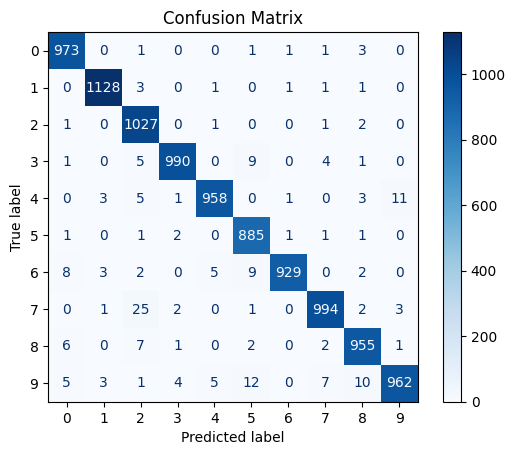

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_probabilities = model.predict(X_test)

y_pred = np.argmax(y_pred_probabilities, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

## Export the model in saved_model (folder format)

In [13]:
model.export("saved_model")
print("Model exported to saved_model/")

import tensorflow as tf
import numpy as np

loaded = tf.saved_model.load("saved_model")
infer  = loaded.signatures["serving_default"]

print("Output keys:", list(infer.structured_outputs.keys()))

# Quick sanity check with a blank image
dummy = tf.constant(np.zeros((1, 28, 28, 1), dtype=np.float32))
out   = infer(dummy)
key   = list(out.keys())[0]
print("Output shape:", out[key].shape)   # should be (1, 10)
print("Inference test passed")

import shutil
from google.colab import files

shutil.make_archive("saved_model", "zip", "saved_model")
files.download("saved_model.zip")
print("saved_model.zip downloaded")


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  133220874935888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133220874937040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133220874937424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133220874936464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133220874937232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133220874934352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133220874935696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133220874934544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133220874938384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133220874938192: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model exported to save

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

saved_model.zip downloaded
